In [1]:
# Configuration
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams.update({'font.size': 12, 'figure.figsize': (14, 8)})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'fm_prelim'

TARGET_COLS = ['r_btc', 'r_gold', 'r_spx']

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {OUTPUT_DIR}")

Project root: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling
Data directory: /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim


In [2]:
# Import custom modules
from modules.finance.evaluation.metrics import (
    diebold_mariano_test,
    apply_fdr_correction,
    get_significance_stars
)

print("Modules imported successfully")

Modules imported successfully


In [3]:
# Load financial data for signed returns
df_clean = pd.read_csv(DATA_DIR / 'financial_returns_and_controls.csv', index_col=0, parse_dates=True)
df_clean = df_clean.sort_index()

print(f"Data loaded: {df_clean.shape}")
print(f"Date range: {df_clean.index.min()} to {df_clean.index.max()}")

Data loaded: (104, 19)
Date range: 2025-01-07 00:00:00 to 2025-05-30 00:00:00


## Load All Model Results

In [4]:
# Define model files
MODEL_FILES = {
    'ARX_baseline': 'arx_baseline_metrics.csv',
    'ARX_emotion': 'arx_emotion_metrics.csv',
    'VARX_baseline': 'varx_baseline_metrics.csv',
    'VARX_emotion': 'varx_emotion_metrics.csv',
}

# Load all results
all_metrics = {}
for model_name, filename in MODEL_FILES.items():
    filepath = OUTPUT_DIR / filename
    if filepath.exists():
        all_metrics[model_name] = pd.read_csv(filepath)
        print(f"✓ Loaded {model_name}")
    else:
        print(f"✗ Missing {model_name} ({filename})")

print(f"\nLoaded {len(all_metrics)}/{len(MODEL_FILES)} model results")

✓ Loaded ARX_baseline
✓ Loaded ARX_emotion
✓ Loaded VARX_baseline
✓ Loaded VARX_emotion

Loaded 4/4 model results


In [5]:
# Combine all metrics into single DataFrame
combined_metrics = pd.concat(all_metrics.values(), ignore_index=True)

# Display full comparison table
print("\n" + "="*80)
print("COMPLETE MODEL COMPARISON")
print("="*80)

display_cols = ['asset', 'model', 'oos_mae', 'oos_rmse', 'oos_r2', 
                'cum_return_strategy']

display_df = combined_metrics[display_cols].copy()
display_df.columns = ['Asset', 'Model', 'MAE', 'RMSE', 'R²', 'Strategy Return']

display(display_df.style.format({
    'MAE': '{:.6f}',
    'RMSE': '{:.6f}',
    'R²': '{:.4f}',
    'Strategy Return': '{:.2%}'
}))


COMPLETE MODEL COMPARISON


,Asset,Model,MAE,RMSE,R²,Strategy Return
0,r_btc,ARX_baseline,0.015244,0.019569,-0.0659,49.22%
1,r_gold,ARX_baseline,0.009057,0.011993,-0.2677,37.16%
2,r_spx,ARX_baseline,0.009901,0.015690,-0.0003,26.52%
3,r_btc,ARX_emotion,0.015191,0.019625,nan,47.12%
4,r_gold,ARX_emotion,0.008487,0.011268,nan,30.72%
5,r_spx,ARX_emotion,0.010048,0.015808,nan,21.11%
6,r_btc,VARX_baseline,0.015416,0.019422,-0.0090,66.76%
7,r_gold,VARX_baseline,0.009696,0.012414,-0.3772,28.02%
8,r_spx,VARX_baseline,0.011813,0.018908,-0.0994,19.37%
9,r_btc,VARX_emotion,0.015928,0.019847,nan,66.84%


## Model Comparison by Asset

In [6]:
# Pivot table for easy comparison
TARGET_COLS = ['r_btc', 'r_gold', 'r_spx']

for metric in ['oos_mae', 'oos_rmse']:
    print(f"\n{'='*60}")
    print(f"{metric.upper().replace('_', ' ')}")
    print('='*60)
    
    pivot = combined_metrics.pivot(index='asset', columns='model', values=metric)
    
    # Reorder columns
    col_order = ['ARX_baseline', 'ARX_emotion', 'VARX_baseline', 'VARX_emotion']
    pivot = pivot[[c for c in col_order if c in pivot.columns]]
    
    # Format based on metric
    # Lower is better for MAE/RMSE
    display(pivot.style.format('{:.6f}').background_gradient(axis=1, cmap='RdYlGn_r'))


OOS MAE


model,ARX_baseline,ARX_emotion,VARX_baseline,VARX_emotion
asset,,,,
r_btc,0.015244,0.015191,0.015416,0.015928
r_gold,0.009057,0.008487,0.009696,0.009531
r_spx,0.009901,0.010048,0.011813,0.010088



OOS RMSE


model,ARX_baseline,ARX_emotion,VARX_baseline,VARX_emotion
asset,,,,
r_btc,0.019569,0.019625,0.019422,0.019847
r_gold,0.011993,0.011268,0.012414,0.012329
r_spx,0.015690,0.015808,0.018908,0.015873


## Best Model Selection

In [7]:
# Find best model for each asset by MAE
print("\n" + "="*60)
print("BEST MODEL BY ASSET (Lowest MAE)")
print("="*60)

best_models = []
for asset in TARGET_COLS:
    asset_data = combined_metrics[combined_metrics['asset'] == asset]
    best_idx = asset_data['oos_mae'].idxmin()
    best_row = asset_data.loc[best_idx]
    
    best_models.append({
        'Asset': asset,
        'Best Model': best_row['model'],
        'MAE': best_row['oos_mae'],
        'RMSE': best_row['oos_rmse'],
        'Strategy Return': best_row['cum_return_strategy']
    })
    
    print(f"\n{asset}:")
    print(f"  Best model: {best_row['model']}")
    print(f"  MAE: {best_row['oos_mae']:.6f}")
    print(f"  Strategy return: {best_row['cum_return_strategy']*100:.2f}%")

best_models_df = pd.DataFrame(best_models)
display(best_models_df)


BEST MODEL BY ASSET (Lowest MAE)

r_btc:
  Best model: ARX_emotion
  MAE: 0.015191
  Strategy return: 47.12%

r_gold:
  Best model: ARX_emotion
  MAE: 0.008487
  Strategy return: 30.72%

r_spx:
  Best model: ARX_baseline
  MAE: 0.009901
  Strategy return: 26.52%


,Asset,Best Model,MAE,RMSE,Strategy Return
0,r_btc,ARX_emotion,0.015191,0.019625,0.471179
1,r_gold,ARX_emotion,0.008487,0.011268,0.307160
2,r_spx,ARX_baseline,0.009901,0.015690,0.265211


## Statistical Comparison: Diebold-Mariano Tests

Pairwise model comparison with FDR correction for multiple testing.

In [8]:
# Load predictions for DM tests
predictions = {}

for model_name in MODEL_FILES.keys():
    model_preds = {}
    for asset in TARGET_COLS:
        # Construct filename
        prefix = model_name.lower().replace('_', '_')
        pred_file = OUTPUT_DIR / f'{prefix}_predictions_{asset}.csv'
        
        if pred_file.exists():
            model_preds[asset] = pd.read_csv(pred_file, index_col='date', parse_dates=True)
    
    if model_preds:
        predictions[model_name] = model_preds

print(f"Loaded predictions for {len(predictions)} models")

Loaded predictions for 4 models


In [9]:
# Pairwise DM tests
if len(predictions) >= 2:
    print("\n" + "="*60)
    print("DIEBOLD-MARIANO PAIRWISE COMPARISONS")
    print("="*60)
    
    dm_results = []
    model_names = list(predictions.keys())
    
    for asset in TARGET_COLS:
        print(f"\n{asset}:")
        
        for i, model1 in enumerate(model_names):
            for j, model2 in enumerate(model_names):
                if i >= j:
                    continue
                
                if asset not in predictions[model1] or asset not in predictions[model2]:
                    continue
                
                preds1 = predictions[model1][asset]
                preds2 = predictions[model2][asset]
                
                # Align dates
                common_dates = preds1.index.intersection(preds2.index)
                if len(common_dates) < 30:
                    continue
                
                p1 = preds1.loc[common_dates]
                p2 = preds2.loc[common_dates]
                
                # Compute forecast errors
                e1 = p1['y_true'].values - p1['y_pred'].values
                e2 = p2['y_true'].values - p2['y_pred'].values
                
                dm_result = diebold_mariano_test(e1, e2, loss_function='SE')
                dm_stat = dm_result['statistic']
                dm_pval = dm_result['pvalue']
                
                dm_results.append({
                    'asset': asset,
                    'model1': model1,
                    'model2': model2,
                    'dm_statistic': dm_stat,
                    'p_value': dm_pval
                })
                
                stars = get_significance_stars(dm_pval)
                better = model1 if dm_stat < 0 else model2
                print(f"  {model1} vs {model2}: p={dm_pval:.4f} {stars} (better: {better})")
    
    # Apply FDR correction
    if dm_results:
        dm_df = pd.DataFrame(dm_results)
        p_values = dm_df['p_value'].values
        rejected, corrected_p, _ = apply_fdr_correction(p_values, alpha=0.05)
        dm_df['p_value_fdr'] = corrected_p
        dm_df['significant_fdr'] = rejected
        
        print("\n" + "="*60)
        print("DM TEST RESULTS WITH FDR CORRECTION")
        print("="*60)
        display(dm_df)
else:
    print("Need at least 2 models with predictions for DM tests")


DIEBOLD-MARIANO PAIRWISE COMPARISONS

r_btc:
  ARX_baseline vs ARX_emotion: p=0.9584  (better: ARX_baseline)
  ARX_baseline vs VARX_baseline: p=0.8377  (better: VARX_baseline)
  ARX_baseline vs VARX_emotion: p=0.9905  (better: VARX_emotion)
  ARX_emotion vs VARX_baseline: p=0.8176  (better: VARX_baseline)
  ARX_emotion vs VARX_emotion: p=0.9775  (better: VARX_emotion)
  VARX_baseline vs VARX_emotion: p=0.5249  (better: VARX_baseline)

r_gold:
  ARX_baseline vs ARX_emotion: p=0.3443  (better: ARX_emotion)
  ARX_baseline vs VARX_baseline: p=0.7481  (better: ARX_baseline)
  ARX_baseline vs VARX_emotion: p=0.7911  (better: ARX_baseline)
  ARX_emotion vs VARX_baseline: p=0.6074  (better: ARX_emotion)
  ARX_emotion vs VARX_emotion: p=0.5845  (better: ARX_emotion)
  VARX_baseline vs VARX_emotion: p=0.6940  (better: VARX_baseline)

r_spx:
  ARX_baseline vs ARX_emotion: p=0.7214  (better: ARX_baseline)
  ARX_baseline vs VARX_baseline: p=0.7355  (better: ARX_baseline)
  ARX_baseline vs VARX_emo

,asset,model1,model2,dm_statistic,p_value,p_value_fdr,significant_fdr
0,r_btc,ARX_baseline,ARX_emotion,-0.052179,0.958386,0.997451,False
1,r_btc,ARX_baseline,VARX_baseline,0.204881,0.837665,0.997451,False
2,r_btc,ARX_baseline,VARX_emotion,0.011967,0.990452,0.997451,False
3,r_btc,ARX_emotion,VARX_baseline,0.230695,0.817552,0.997451,False
4,r_btc,ARX_emotion,VARX_emotion,0.028246,0.977466,0.997451,False
5,r_btc,VARX_baseline,VARX_emotion,-0.635813,0.524899,0.997451,False
6,r_gold,ARX_baseline,ARX_emotion,0.945788,0.344257,0.997451,False
7,r_gold,ARX_baseline,VARX_baseline,-0.321207,0.748054,0.997451,False
8,r_gold,ARX_baseline,VARX_emotion,-0.264906,0.791082,0.997451,False
9,r_gold,ARX_emotion,VARX_baseline,-0.513753,0.607424,0.997451,False


## Visualization: Model Performance Comparison

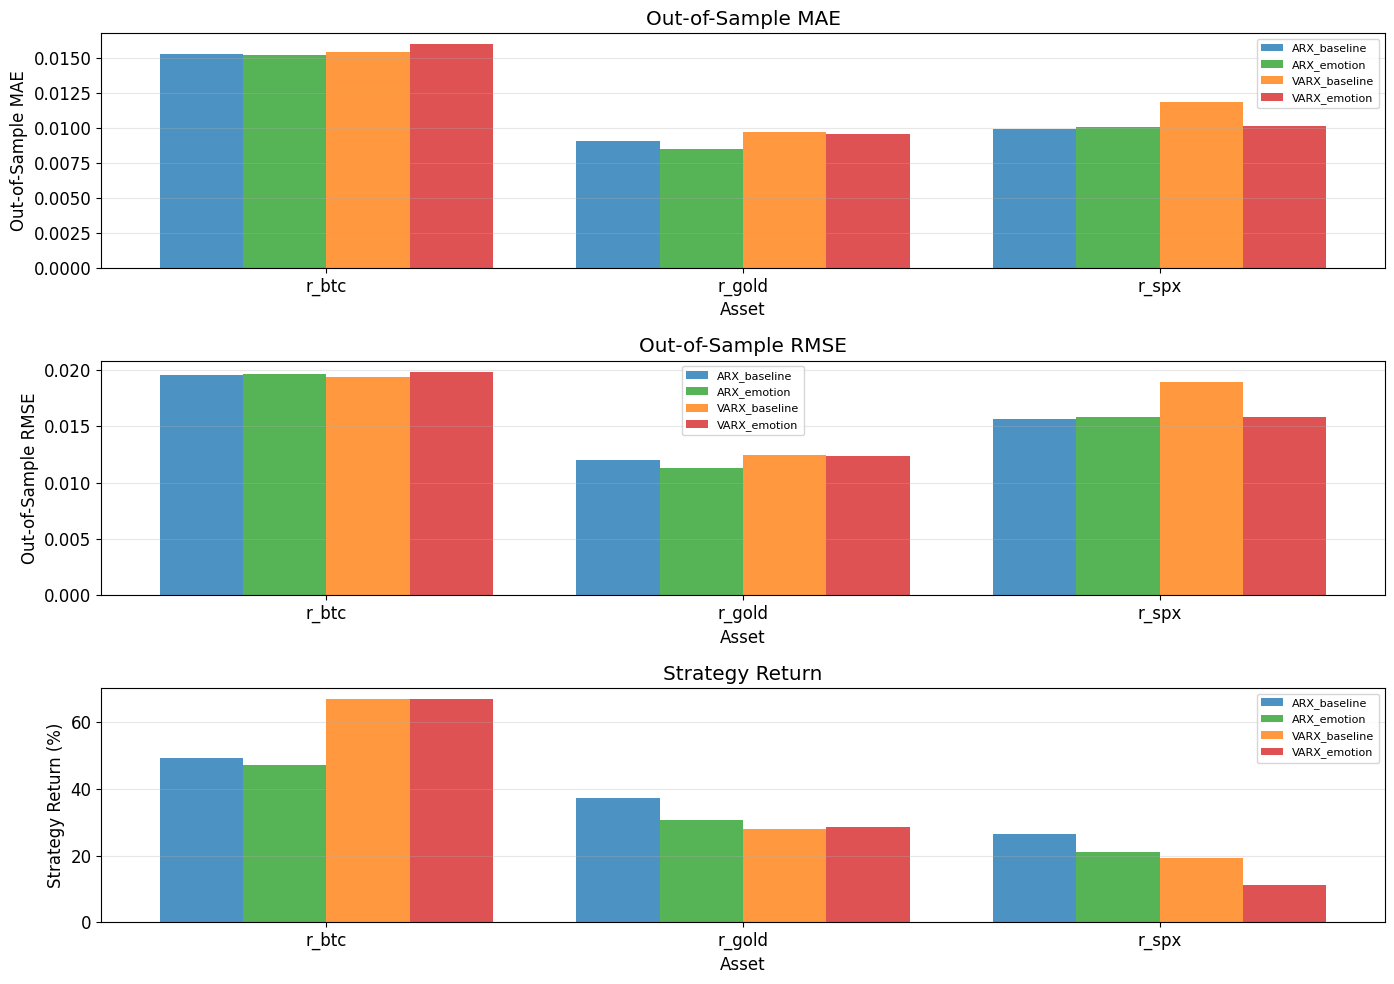

In [10]:
# Bar chart comparison
fig, axes = plt.subplots(3,1, figsize=(14, 10))

metrics_to_plot = [
    ('oos_mae', 'Out-of-Sample MAE', True),
    ('oos_rmse', 'Out-of-Sample RMSE', True),
    ('cum_return_strategy', 'Strategy Return', False)
]

for ax, (metric, title, lower_better) in zip(axes.flatten(), metrics_to_plot):
    pivot = combined_metrics.pivot(index='asset', columns='model', values=metric)
    col_order = ['ARX_baseline', 'ARX_emotion', 'VARX_baseline', 'VARX_emotion']
    pivot = pivot[[c for c in col_order if c in pivot.columns]]
    
    x = np.arange(len(pivot.index))
    width = 0.2
    
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
    
    for i, (col, color) in enumerate(zip(pivot.columns, colors)):
        values = pivot[col].values
        if metric in ['cum_return_strategy']:
            values = values * 100  # Convert to percentage
        ax.bar(x + i*width, values, width, label=col, color=color, alpha=0.8)
    
    ax.set_xlabel('Asset')
    ax.set_ylabel(title + (' (%)' if metric in ['cum_return_strategy'] else ''))
    ax.set_title(title)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(pivot.index)
    ax.legend(loc='best', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()


IMPROVEMENT OVER BASELINE (%)


,Asset,Comparison,MAE Improvement (%)
0,r_btc,ARX: Baseline → Emotion,+0.35
1,r_btc,VARX: Baseline → Emotion,-3.32
2,r_gold,ARX: Baseline → Emotion,+6.30
3,r_gold,VARX: Baseline → Emotion,+1.71
4,r_spx,ARX: Baseline → Emotion,-1.48
5,r_spx,VARX: Baseline → Emotion,+14.60


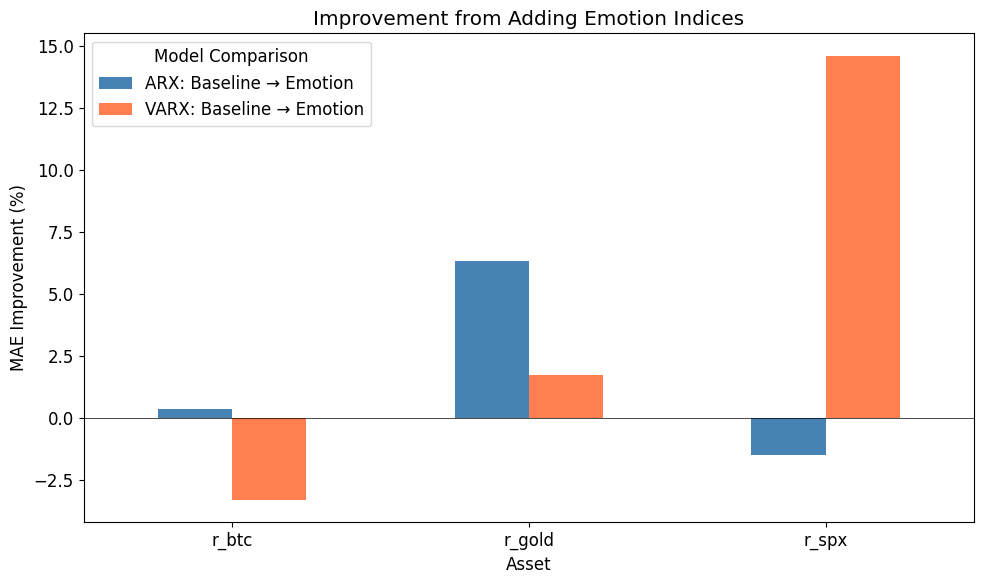

In [11]:
# Improvement over baseline visualization
print("\n" + "="*60)
print("IMPROVEMENT OVER BASELINE (%)")
print("="*60)

improvement_data = []

for asset in TARGET_COLS:
    asset_data = combined_metrics[combined_metrics['asset'] == asset]
    
    # Get baselines
    arx_baseline = asset_data[asset_data['model'] == 'ARX_baseline'].iloc[0] if 'ARX_baseline' in asset_data['model'].values else None
    varx_baseline = asset_data[asset_data['model'] == 'VARX_baseline'].iloc[0] if 'VARX_baseline' in asset_data['model'].values else None
    
    # ARX improvement
    if arx_baseline is not None:
        arx_emotion = asset_data[asset_data['model'] == 'ARX_emotion']
        if len(arx_emotion) > 0:
            arx_emotion = arx_emotion.iloc[0]
            mae_imp = (arx_baseline['oos_mae'] - arx_emotion['oos_mae']) / arx_baseline['oos_mae'] * 100
            improvement_data.append({
                'Asset': asset,
                'Comparison': 'ARX: Baseline → Emotion',
                'MAE Improvement (%)': mae_imp,
            })
    
    # VARX improvement
    if varx_baseline is not None:
        varx_emotion = asset_data[asset_data['model'] == 'VARX_emotion']
        if len(varx_emotion) > 0:
            varx_emotion = varx_emotion.iloc[0]
            mae_imp = (varx_baseline['oos_mae'] - varx_emotion['oos_mae']) / varx_baseline['oos_mae'] * 100
            improvement_data.append({
                'Asset': asset,
                'Comparison': 'VARX: Baseline → Emotion',
                'MAE Improvement (%)': mae_imp,
            })

if improvement_data:
    improvement_df = pd.DataFrame(improvement_data)
    display(improvement_df.style.format({'MAE Improvement (%)': '{:+.2f}'}).background_gradient(
        subset=['MAE Improvement (%)'], cmap='RdYlGn'))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot = improvement_df.pivot(index='Asset', columns='Comparison', values='MAE Improvement (%)')
    pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('MAE Improvement (%)')
    ax.set_title('Improvement from Adding Emotion Indices')
    ax.legend(title='Model Comparison')
    ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'emotion_improvement.png', dpi=150, bbox_inches='tight')
    plt.show()

## Significant Emotion Features Summary

Aggregate significant emotion features across all models.

In [12]:
# Load bootstrap results
bootstrap_files = [
    'arx_emotion_bootstrap.csv',
    'varx_emotion_bootstrap.csv'
]

all_bootstrap = []
for file in bootstrap_files:
    filepath = OUTPUT_DIR / file
    if filepath.exists():
        df = pd.read_csv(filepath)
        df['source'] = file.replace('_bootstrap.csv', '')
        all_bootstrap.append(df)

if all_bootstrap:
    bootstrap_df = pd.concat(all_bootstrap, ignore_index=True)
    
    print("\n" + "="*60)
    print("SIGNIFICANT EMOTION FEATURES ACROSS MODELS")
    print("="*60)
    
    # Filter significant features (exclude AR and control)
    control_patterns = ['AR_lag', 'dln_', 'dy10']
    target_patterns = ['r_btc', 'r_gold', 'r_spx']
    
    emotion_mask = ~bootstrap_df['feature'].apply(
        lambda x: any(p in x for p in control_patterns + target_patterns)
    )
    sig_mask = bootstrap_df['sig_95']  # Column is sig_95, not significant_0.05
    
    sig_emotion = bootstrap_df[emotion_mask & sig_mask].copy()
    
    if len(sig_emotion) > 0:
        # Count how often each feature is significant
        feature_counts = sig_emotion.groupby('feature').agg({
            'sig_95': 'sum',
            'boot_mean': lambda x: x.mean()
        }).reset_index()
        feature_counts.columns = ['Feature', 'Sig. Count', 'Avg. Coefficient']
        feature_counts = feature_counts.sort_values('Sig. Count', ascending=False)
        
        print(f"\nTop 20 most frequently significant emotion features:")
        display(feature_counts.head(20).style.format({
            'Avg. Coefficient': '{:.6f}'
        }))
        
        # By asset
        print("\nSignificant emotion features by asset:")
        for asset in TARGET_COLS:
            asset_sig = sig_emotion[sig_emotion['asset'] == asset]
            print(f"\n  {asset}: {len(asset_sig)} significant features")
    else:
        print("No significant emotion features found.")
else:
    print("No bootstrap results found.")


SIGNIFICANT EMOTION FEATURES ACROSS MODELS

Top 20 most frequently significant emotion features:


,Feature,Sig. Count,Avg. Coefficient
0,y_lag1,1,0.002303



Significant emotion features by asset:

  r_btc: 0 significant features

  r_gold: 1 significant features

  r_spx: 0 significant features


## Cumulative Returns Comparison

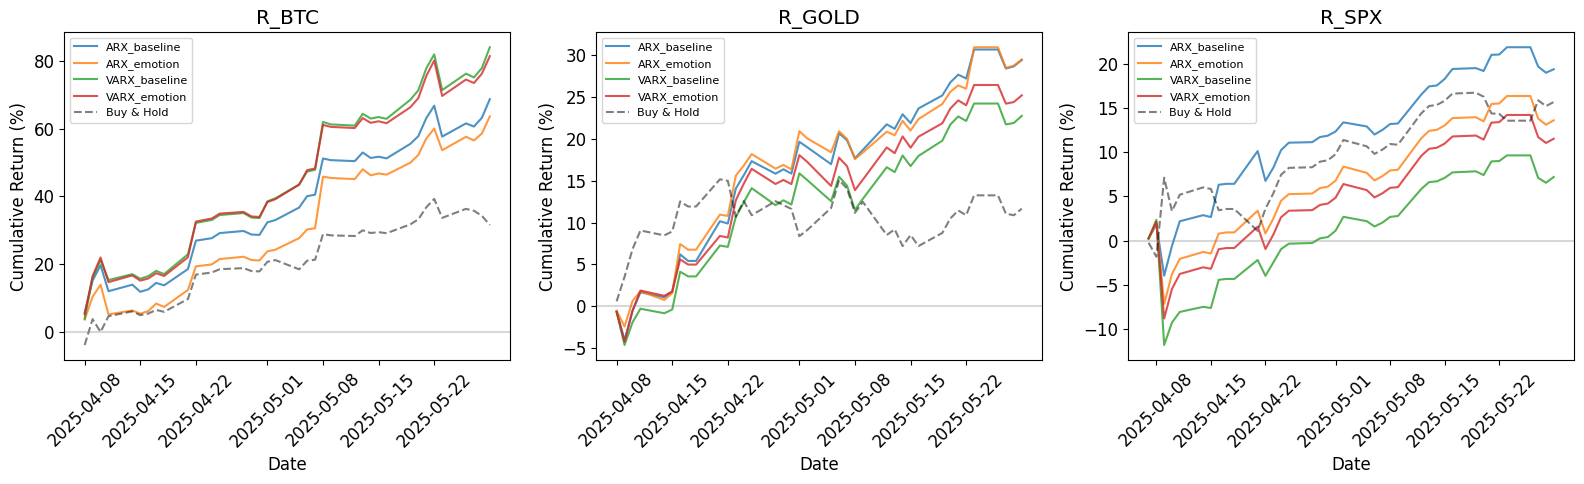

In [13]:
# Plot cumulative returns for all models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, asset in enumerate(TARGET_COLS):
    ax = axes[idx]
    
    # First, find common dates across ALL models for this asset
    all_dates = []
    for model_name, preds_dict in predictions.items():
        if asset in preds_dict:
            all_dates.append(preds_dict[asset].index)
    
    if len(all_dates) == 0:
        print(f"Warning: No predictions for {asset}")
        continue
    
    # Get intersection of all model dates
    common_dates = all_dates[0]
    for dates in all_dates[1:]:
        common_dates = common_dates.intersection(dates)
    
    # Also intersect with df_clean dates
    common_dates = common_dates.intersection(df_clean.index)
    
    if len(common_dates) == 0:
        print(f"Warning: No common dates across all models for {asset}")
        continue
    
    # Get signed returns column
    asset_name = asset.replace('r_', '')
    signed_col = f'r_{asset_name}_signed'
    
    if signed_col not in df_clean.columns:
        print(f"Warning: {signed_col} not found in data")
        continue
    
    # Now plot all models using the same date range
    for model_name, preds_dict in predictions.items():
        if asset in preds_dict:
            preds = preds_dict[asset]
            
            # Get actual signed returns
            actual_returns = df_clean.loc[common_dates, signed_col].values
            
            # Get momentum signal and compute strategy returns
            momentum_col = f'momentum_5d_{asset_name}'
            if momentum_col in df_clean.columns:
                momentum_signal = np.sign(df_clean.loc[common_dates, momentum_col].values)
            else:
                # Fallback: use sign of predictions
                momentum_signal = np.sign(preds.loc[common_dates, 'y_pred'].values)
            
            # Inverse volatility weighting using predicted volatility
            predicted_vol = preds.loc[common_dates, 'y_pred'].values
            # Cap and floor positions
            vol_cap = np.percentile(predicted_vol, 95)
            vol_floor = np.percentile(predicted_vol, 5)
            predicted_vol_clipped = np.clip(predicted_vol, vol_floor, vol_cap)
            positions = momentum_signal / (predicted_vol_clipped + 1e-8)
            positions = positions / np.std(positions)  # Normalize to comparable scale
            
            strategy_returns = positions * actual_returns
            cum_strategy = np.cumprod(1 + strategy_returns) - 1
            
            ax.plot(common_dates, cum_strategy * 100, label=model_name, alpha=0.8)
    
    # Add buy & hold using the same common dates
    actual_returns = df_clean.loc[common_dates, signed_col].values
    cum_buy_hold = np.cumprod(1 + actual_returns) - 1
    ax.plot(common_dates, cum_buy_hold * 100, label='Buy & Hold', 
            color='black', linestyle='--', alpha=0.5)
    
    ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
    ax.set_title(f'{asset.upper()}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Cumulative Return (%)')
    ax.legend(loc='best', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_models_cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

## Executive Summary

In [14]:
# Generate executive summary
print("\n" + "="*80)
print("EXECUTIVE SUMMARY")
print("="*80)

print("\n1. MODEL PERFORMANCE RANKING (by average MAE across assets):")
model_avg_mae = combined_metrics.groupby('model')['oos_mae'].mean().sort_values()
for i, (model, mae) in enumerate(model_avg_mae.items(), 1):
    print(f"   {i}. {model}: {mae:.6f}")

print("\n2. EMOTION INDEX CONTRIBUTION:")
for asset in TARGET_COLS:
    asset_data = combined_metrics[combined_metrics['asset'] == asset]
    
    # ARX comparison
    arx_base = asset_data[asset_data['model'] == 'ARX_baseline']['oos_mae'].values
    arx_emo = asset_data[asset_data['model'] == 'ARX_emotion']['oos_mae'].values
    
    if len(arx_base) > 0 and len(arx_emo) > 0:
        imp = (arx_base[0] - arx_emo[0]) / arx_base[0] * 100
        direction = "improved" if imp > 0 else "worsened"
        print(f"   {asset}: ARX {direction} by {abs(imp):.2f}% with emotion indices")

print("\n3. BEST MODEL PER ASSET:")
for _, row in best_models_df.iterrows():
    print(f"   {row['Asset']}: {row['Best Model']} (MAE: {row['MAE']:.6f})")

print("\n4. KEY FINDINGS:")
# Calculate overall statistics
if 'ARX_emotion' in all_metrics and 'ARX_baseline' in all_metrics:
    emo_better_count = sum(
        all_metrics['ARX_emotion'][all_metrics['ARX_emotion']['asset'] == a]['oos_mae'].values[0] <
        all_metrics['ARX_baseline'][all_metrics['ARX_baseline']['asset'] == a]['oos_mae'].values[0]
        for a in TARGET_COLS
    )
    print(f"   - Emotion indices improved ARX forecasts for {emo_better_count}/{len(TARGET_COLS)} assets")

print("\n" + "="*80)


EXECUTIVE SUMMARY

1. MODEL PERFORMANCE RANKING (by average MAE across assets):
   1. ARX_emotion: 0.011242
   2. ARX_baseline: 0.011401
   3. VARX_emotion: 0.011849
   4. VARX_baseline: 0.012308

2. EMOTION INDEX CONTRIBUTION:
   r_btc: ARX improved by 0.35% with emotion indices
   r_gold: ARX improved by 6.30% with emotion indices
   r_spx: ARX worsened by 1.48% with emotion indices

3. BEST MODEL PER ASSET:
   r_btc: ARX_emotion (MAE: 0.015191)
   r_gold: ARX_emotion (MAE: 0.008487)
   r_spx: ARX_baseline (MAE: 0.009901)

4. KEY FINDINGS:
   - Emotion indices improved ARX forecasts for 2/3 assets



## Save Summary Report

In [15]:
# Save combined results
combined_metrics.to_csv(OUTPUT_DIR / 'all_models_metrics.csv', index=False)
print(f"Saved combined metrics to {OUTPUT_DIR / 'all_models_metrics.csv'}")

# Save best models
best_models_df.to_csv(OUTPUT_DIR / 'best_models_summary.csv', index=False)
print(f"Saved best models summary to {OUTPUT_DIR / 'best_models_summary.csv'}")

# Save DM test results if available
if 'dm_df' in dir() and dm_df is not None:
    dm_df.to_csv(OUTPUT_DIR / 'dm_test_results.csv', index=False)
    print(f"Saved DM test results to {OUTPUT_DIR / 'dm_test_results.csv'}")

print("\n✅ Summary report saved successfully!")

Saved combined metrics to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/all_models_metrics.csv
Saved best models summary to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/best_models_summary.csv
Saved DM test results to /Users/briceshun/Documents/PhD 2022/youtube-emotion-financial-modelling/data/fm_prelim/dm_test_results.csv

✅ Summary report saved successfully!


In [16]:
# Diagnostic: Compare predictions across models
print("\n" + "="*80)
print("PREDICTION COMPARISON DIAGNOSTICS")
print("="*80)

for asset in TARGET_COLS:
    print(f"\n{asset.upper()}:")
    print("-" * 60)
    
    for model_name, preds_dict in predictions.items():
        if asset in preds_dict:
            preds = preds_dict[asset]
            pred_values = preds['y_pred'].values
            
            print(f"\n{model_name}:")
            print(f"  Mean prediction:   {np.mean(pred_values):.6f}")
            print(f"  Std prediction:    {np.std(pred_values):.6f}")
            print(f"  Min prediction:    {np.min(pred_values):.6f}")
            print(f"  Max prediction:    {np.max(pred_values):.6f}")
            print(f"  Range:             {np.max(pred_values) - np.min(pred_values):.6f}")
            
            # Check if predictions vary
            if np.std(pred_values) < 0.001:
                print(f"  ⚠️  WARNING: Predictions barely vary!")
    
    # Also check y_true
    if predictions:
        first_model = list(predictions.keys())[0]
        if asset in predictions[first_model]:
            y_true = predictions[first_model][asset]['y_true'].values
            print(f"\nActual returns (y_true):")
            print(f"  Mean:  {np.mean(y_true):.6f}")
            print(f"  Std:   {np.std(y_true):.6f}")
            print(f"  Range: {np.max(y_true) - np.min(y_true):.6f}")



PREDICTION COMPARISON DIAGNOSTICS

R_BTC:
------------------------------------------------------------

ARX_baseline:
  Mean prediction:   0.022426
  Std prediction:    0.003349
  Min prediction:    0.013410
  Max prediction:    0.028633
  Range:             0.015223

ARX_emotion:
  Mean prediction:   0.023255
  Std prediction:    0.006950
  Min prediction:    0.006938
  Max prediction:    0.036223
  Range:             0.029284

VARX_baseline:
  Mean prediction:   0.022600
  Std prediction:    0.005591
  Min prediction:    0.014964
  Max prediction:    0.049730
  Range:             0.034766

VARX_emotion:
  Mean prediction:   0.021845
  Std prediction:    0.000929
  Min prediction:    0.020579
  Max prediction:    0.023571
  Range:             0.002992
  ⚠️  WARNING: Predictions barely vary!

Actual returns (y_true):
  Mean:  0.017974
  Std:   0.018954
  Range: 0.078567

R_GOLD:
------------------------------------------------------------

ARX_baseline:
  Mean prediction:   0.010181
 